# Food & Restaurant AI Demand Forecasting using Time-Series Machine Learning
# Week 3 Model Training

This project focuses on forecasting daily food demand using historical sales data. The goal is to build a reliable machine learning pipeline that captures temporal patterns such as trends, seasonality, and past dependencies to predict future demand.

The workflow includes:
- Feature engineering using time-series techniques
- Training multiple machine learning models
- Hyperparameter tuning using time-aware validation
- Model evaluation and comparison
- Interpretation using feature importance

This project follows a structured approach to ensure realistic forecasting and avoid data leakage.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor

## Data Loading

In this step, we load the processed dataset generated from the feature engineering phase. The dataset includes lag features, rolling statistics, and time-based features required for time-series modeling.

This ensures that the model has access to historical patterns and temporal signals necessary for accurate forecasting.

In [2]:
# Loading engineered dataset (from Week 2)
df = pd.read_csv('../data/processed/model_ready_data.csv')

df.head()

,date,quantity,day,month,year,day_of_week,week_of_year,is_weekend,day_of_week_sin,day_of_week_cos,...,lag_3,lag_7,lag_14,lag_21,rolling_mean_3,rolling_std_3,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14
0,2024-04-22,410,22,4,2024,0,17,0,0.000000,1.000000,...,476.0,429.0,444.0,475.0,494.666667,18.502252,473.142857,29.288385,463.357143,27.886051
1,2024-04-23,405,23,4,2024,1,17,0,0.781831,0.623490,...,495.0,460.0,426.0,456.0,472.666667,55.012120,470.428571,34.481189,460.928571,31.007355
2,2024-04-24,455,24,4,2024,2,17,0,0.974928,-0.222521,...,513.0,491.0,474.0,466.0,442.666667,60.961737,462.571429,42.570949,459.428571,33.253604
3,2024-04-25,486,25,4,2024,3,17,0,0.433884,-0.900969,...,410.0,448.0,449.0,415.0,423.333333,27.537853,457.428571,40.697490,458.071429,32.999917
4,2024-04-26,512,26,4,2024,4,17,0,-0.433884,-0.900969,...,405.0,476.0,493.0,446.0,448.666667,40.869712,462.857143,41.750962,460.714286,33.691881


## Feature and Target Selection

The target variable is the daily quantity sold.

The feature set includes:
- Lag features representing past demand
- Rolling statistics capturing short-term trends
- Time-based features such as day of week and month

The date column is excluded from modeling as it is not directly usable by machine learning algorithms.

In [3]:
# Target variable
y = df['quantity']

# (drop target + date)
X = df.drop(['quantity', 'date'], axis=1)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (344, 22)
Target shape: (344,)


## Time-Series Train-Test Split

The dataset is split into training and testing sets based on chronological order.

Unlike traditional machine learning, time-series data must preserve temporal order to avoid data leakage. The model is trained on past data and evaluated on future data to simulate real-world forecasting scenarios.

In [4]:
# Time-Series Train-Test Split

train_size = int(len(X) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (275, 22)
X_test: (69, 22)


## Naive Baseline Model

A naive baseline is used to establish a minimum performance benchmark.

The baseline assumes that the demand for the next day is equal to the previous day's demand. This simple approach is commonly used in time-series forecasting and provides a reference point to evaluate whether machine learning models add value.

In [5]:
# Naive Baseline (previous day's value)

naive_pred = X_test['lag_1']

mae_naive = mean_absolute_error(y_test, naive_pred)
rmse_naive = np.sqrt(mean_squared_error(y_test, naive_pred))

print("Naive MAE:", mae_naive)
print("Naive RMSE:", rmse_naive)

Naive MAE: 39.04347826086956
Naive RMSE: 49.6033542577837


## Feature Scaling for Linear Models

In [6]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Scale features (fit only on train!)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Linear Regression Model

Linear Regression is used as a simple baseline machine learning model.

It helps in understanding whether a linear relationship between features and target exists and provides a comparison point for more complex models.

In [7]:
# Linear regression

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

In [8]:
mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))

print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)

Linear Regression MAE: 29.030328463513765
Linear Regression RMSE: 35.45321068169522


## Random Forest Model

Random Forest is an ensemble learning method that combines multiple decision trees to improve prediction accuracy.

It is capable of capturing non-linear relationships and interactions between features, making it more powerful than simple linear models.

In [9]:
# Random Forest

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [10]:
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest MAE: 30.932463768115937
Random Forest RMSE: 36.44733257968151


## XGBoost Model

XGBoost is a gradient boosting algorithm known for its high performance and efficiency.

It builds trees sequentially, where each new tree corrects the errors of the previous ones. This makes it highly effective for structured data and time-series feature-based modeling.

In [11]:
# XGBoost

xgb = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

In [12]:
mae_xgb = mean_absolute_error(y_test, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)

XGBoost MAE: 36.52853012084961
XGBoost RMSE: 42.681788943551496


## Hyperparameter Tuning with Time-Series Cross Validation

To improve model performance, hyperparameter tuning is performed using GridSearchCV.

TimeSeriesSplit is used instead of random cross-validation to ensure that training always occurs on past data and validation on future data. This preserves the temporal structure and prevents data leakage.

The goal is to find the best combination of parameters that minimizes prediction error.

In [13]:
# TimeSeries tuning

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from xgboost import XGBRegressor

# Time-Series Cross Validation
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

grid = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

# Predictions from tuned model
pred_tuned = best_model.predict(X_test)

## Model Evaluation

Models are evaluated using the following metrics:

- Mean Absolute Error (MAE): Measures the average magnitude of errors
- Root Mean Squared Error (RMSE): Penalizes larger errors more heavily

These metrics help compare model performance and determine which approach generalizes best to unseen data.

In [14]:
# Evaluation

mae_tuned = mean_absolute_error(y_test, pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, pred_tuned))

print("Tuned XGBoost MAE:", mae_tuned)
print("Tuned XGBoost RMSE:", rmse_tuned)
print("Best Params:", grid.best_params_)

Tuned XGBoost MAE: 28.178136825561523
Tuned XGBoost RMSE: 33.71629176048465
Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}


## Overfitting Check (Train vs Test Error)

In [15]:
# Predictions on training data
train_pred = best_model.predict(X_train)

# Train metrics
mae_train = mean_absolute_error(y_train, train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, train_pred))

# Test metrics (already computed earlier)
print("Train MAE:", mae_train)
print("Test MAE:", mae_tuned)

print("Train RMSE:", rmse_train)
print("Test RMSE:", rmse_tuned)

Train MAE: 22.663742065429688
Test MAE: 28.178136825561523
Train RMSE: 28.88426000565392
Test RMSE: 33.71629176048465


## Model Comparison

All models are compared based on their performance metrics.

The comparison helps identify:
- Whether machine learning models outperform the naive baseline
- Which model provides the best trade-off between bias and variance

The best-performing model is selected for final forecasting.

In [16]:
# Results

results = pd.DataFrame({
    "Model": ["Naive", "Linear Regression", "Random Forest", "XGBoost", "Tuned XGBoost"],
    "MAE": [mae_naive, mae_lr, mae_rf, mae_xgb, mae_tuned],
    "RMSE": [rmse_naive, rmse_lr, rmse_rf, rmse_xgb, rmse_tuned]
})

results.sort_values(by="MAE")

,Model,MAE,RMSE
4,Tuned XGBoost,28.178137,33.716292
1,Linear Regression,29.030328,35.453211
2,Random Forest,30.932464,36.447333
3,XGBoost,36.528530,42.681789
0,Naive,39.043478,49.603354


In [17]:
print("\n Model Comparison (Sorted by MAE):")
print(results.sort_values(by="MAE"))


 Model Comparison (Sorted by MAE):
               Model        MAE       RMSE
4      Tuned XGBoost  28.178137  33.716292
1  Linear Regression  29.030328  35.453211
2      Random Forest  30.932464  36.447333
3            XGBoost  36.528530  42.681789
0              Naive  39.043478  49.603354


## Best Model

In [18]:
best_model_name = results.sort_values(by="MAE").iloc[0]["Model"]
print(f"\n Best Model: {best_model_name}")


 Best Model: Tuned XGBoost


## Saving Trained Model

In [19]:
import joblib

joblib.dump(best_model, '../models/xgboost_model.pkl')

print("Correct model saved")

Correct model saved


## Actual vs Predicted Visualization

A line plot is used to compare actual demand with predicted demand.

This visualization helps in:
- Understanding how well the model tracks real trends
- Identifying patterns such as lag, overfitting, or underfitting

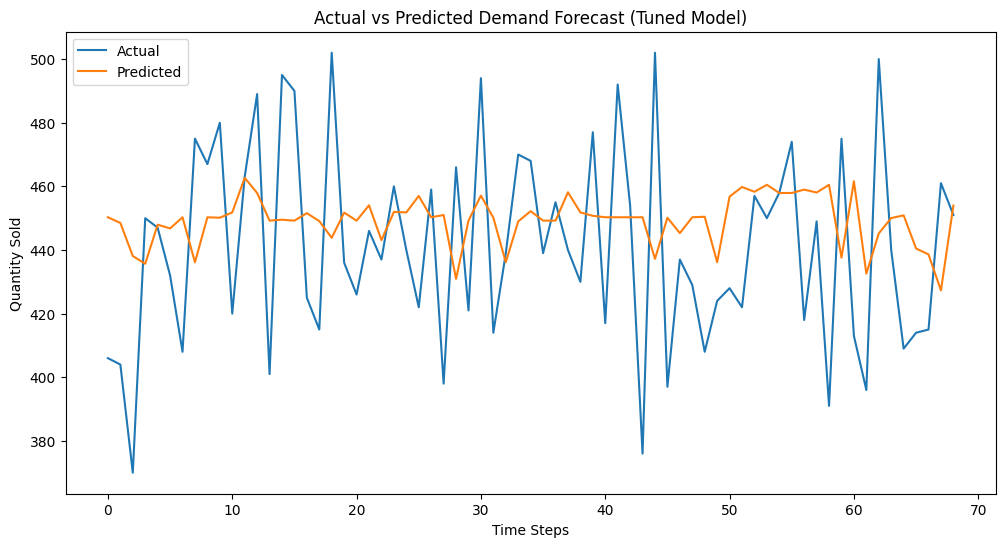

In [20]:
plt.figure(figsize=(12,6))

plt.plot(y_test.reset_index(drop=True), label="Actual")
plt.plot(pd.Series(pred_tuned), label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Demand Forecast (Tuned Model)")
plt.xlabel("Time Steps")
plt.ylabel("Quantity Sold")

plt.show()

## Residual Analysis

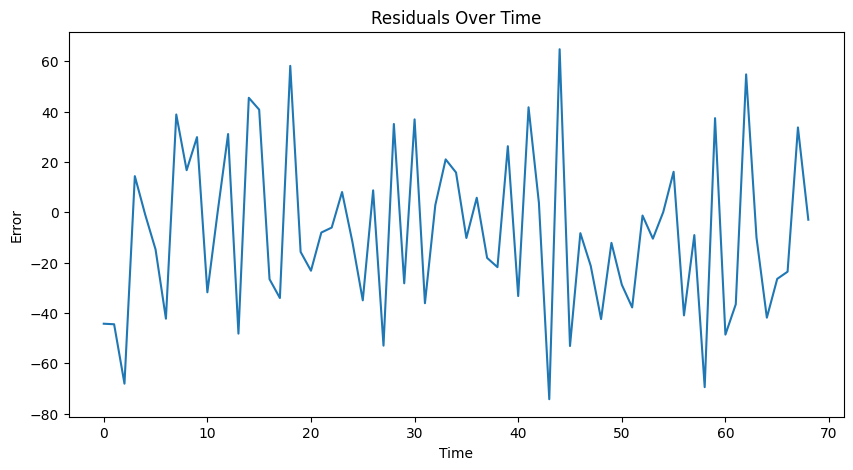

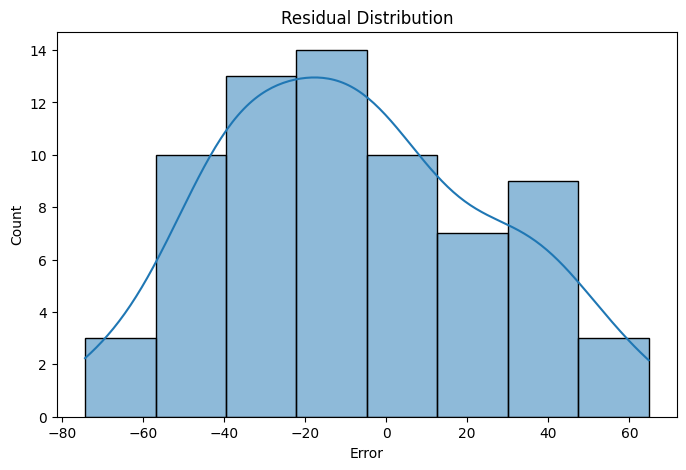

In [21]:
# Residuals
residuals = y_test.reset_index(drop=True) - pd.Series(pred_tuned)

plt.figure(figsize=(10,5))
plt.plot(residuals)
plt.title("Residuals Over Time")
plt.xlabel("Time")
plt.ylabel("Error")
plt.show()

# Distribution
plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.show()

## Feature Importance Analysis

Feature importance from the tuned XGBoost model is used to interpret model behavior.

This helps identify:
- Which features contribute most to predictions
- The significance of lag and rolling features
- Key drivers of demand patterns

This step adds interpretability and business value to the model.

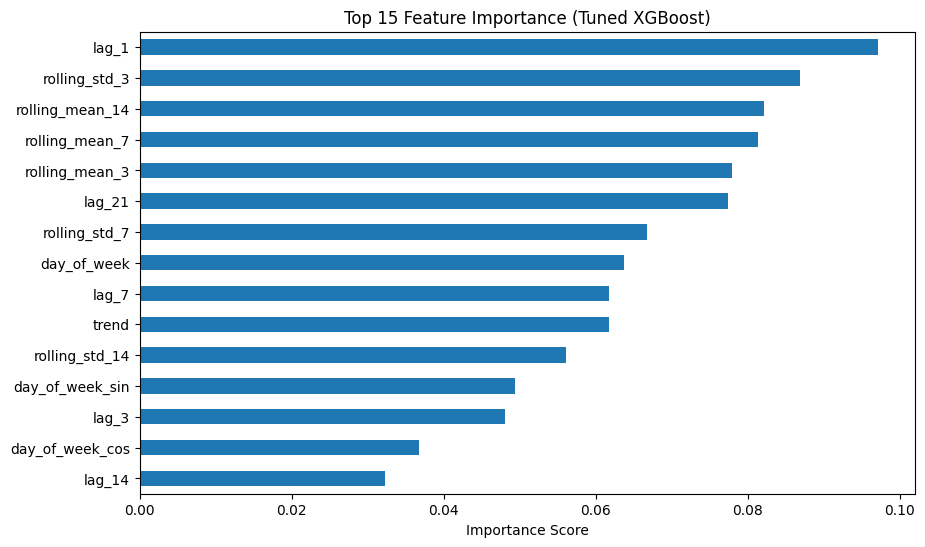

Top 10 Important Features:
lag_1              0.097111
rolling_std_3      0.086922
rolling_mean_14    0.082176
rolling_mean_7     0.081327
rolling_mean_3     0.077909
lag_21             0.077402
rolling_std_7      0.066749
day_of_week        0.063740
lag_7              0.061755
trend              0.061713
dtype: float32


In [22]:
# Feature Importance

importance = best_model.feature_importances_
features = X.columns

feat_imp = pd.Series(importance, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.head(15).plot(kind='barh')
plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importance (Tuned XGBoost)")
plt.xlabel("Importance Score")

plt.show()

# Print top features
print("Top 10 Important Features:")
print(feat_imp.head(10))

## Feature Importance Insights

## Key Insights from Feature Importance

- Lag features (especially lag_7, lag_1) are among the most important predictors, indicating strong temporal dependency in demand.
- Rolling mean features contribute significantly, showing that recent trends influence future sales.
- Time-based features like day_of_week also impact predictions, reflecting weekly seasonality.
- This confirms that demand is driven by both recent history and cyclical patterns.

Business Impact:
- Helps in inventory planning based on recent demand trends
- Enables better staffing decisions during high-demand days

## Conclusion

This project demonstrates a complete time-series forecasting pipeline using machine learning.

Key takeaways:
- Feature engineering plays a critical role in time-series modeling
- Naive baseline provides an essential benchmark
- Advanced models like XGBoost significantly improve prediction accuracy
- Time-aware validation is necessary to avoid data leakage

The final model can be used to support demand planning and operational decisions in a food restaurant setting.